# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

['\ufefft (min)' 't (oC)']


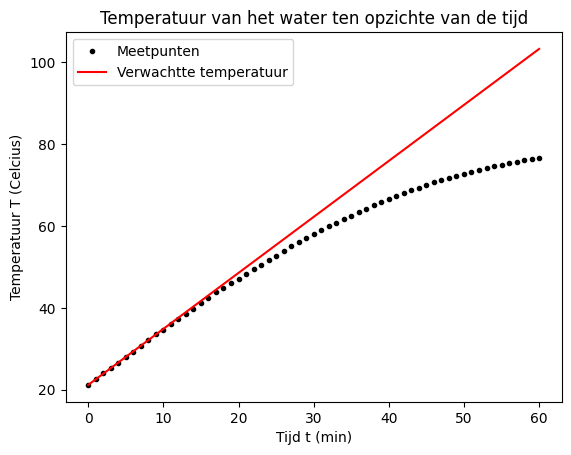

a= 1.3666666668448983


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
#De data is via Félicie's computer geladen dus de path werkt alleen op die van haar.
fileName = '/Users/felicievanderleij/Desktop/Project/Thermoproject/Felicie-Amelie/Content/Labs/tempmetingen-46931600a9ec9432720d281e3972dd50.csv'

#laden van de header met de namen van de grootheden
header = np.loadtxt(fileName, delimiter=';', max_rows=1, dtype=str)
print(header)  

#Laden van de rest van de data
data = np.loadtxt(fileName, delimiter=';', skiprows=1)
data = data.T
t = data[0]
T = data[1]

def verwachting(x, a, b) :
    return a*x + b
popt, pcov = curve_fit(verwachting, t[:10], T[:10])
a, b = popt
T_ideaal=verwachting(t,a,b)

#plot
plt.figure()
plt.plot(t,T, "k.", label="Meetpunten")
plt.plot(t, T_ideaal, "r-", label="Verwachtte temperatuur")
plt.xlabel("Tijd t (min)")
plt.ylabel("Temperatuur T (Celcius)")
plt.legend()
plt.title("Temperatuur van het water ten opzichte van de tijd")
plt.show() 
print("a=", popt[0])

#

In [19]:
m_maatbeker = 820.8
m_begin = 1292.9 - m_maatbeker
m_eind = 1274.9 - m_maatbeker

m_water_verdampt = np.abs(m_begin - m_eind)
print(m_water_verdampt, "g")

18.0 g


In [37]:
Temperatuur_verrandering = np.abs(T[0]- T[60])
print("Temperatuur verrandering =", Temperatuur_verrandering, "Celcius")
c_water = 4.18
energie_opwarming = m_begin * c_water * Temperatuur_verrandering
print("Energie opwarming =",energie_opwarming, "J")
Lv_water =2.26e3
energie_verdamping = m_water_verdampt * Lv_water
print("Energie verdamping =", energie_verdamping, "J")
totaal_energie = energie_opwarming+energie_verdamping
print("Totaal energie =", totaal_energie, "J")

Temperatuur verrandering = 55.39999999999999 Celcius
Energie opwarming = 109325.1412 J
Energie verdamping = 40680.0 J
Totaal energie = 150005.1412 J


In [35]:
Vermogen = (c_water * m_begin * popt[0])
print("Vermogen =", Vermogen, "W")
Energie_toegevoegd = Vermogen * 60
print("Energie toegevoegd =", Energie_toegevoegd, "J")

Vermogen = 2696.949933685052 W
Energie toegevoegd = 161816.99602110314 J


In [ ]:
# We merken dat de toegevoegde energie 1.6e5 J, vergelijkbaar is met de energie nodig voor opwarming
# en verdamping van het water 1.5e5 J. Er wordt heel klein verlies gemaakt.

# Aannames : Alle massa verlies is door verdamping veroorzaakt, constant vermogen, constant c_water, 
# niet precies meenemen van warmte verlies aan lucht of matbeker.



In [ ]:
#Manieren om dit experiment te verbeteren, zijn als eerste het isoleren van de beker. Zo zal er minder
# warmte verloren gaan aan de omgeving. Ook kan je bijvoorbeeld de beker afdekken maar er een gaatje in
# prikken voor de thermometer, zodat er minder verdampt. Als laatste is het belangrijk om de temperatuur
# homogeen te houden dus door regelmatig te roeren.
